<a href="https://colab.research.google.com/github/Raskovm/Machine_learning_kernels/blob/main/Os_Kernels.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn import datasets
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from ipywidgets import interact, fixed
from mpl_toolkits.mplot3d import Axes3D

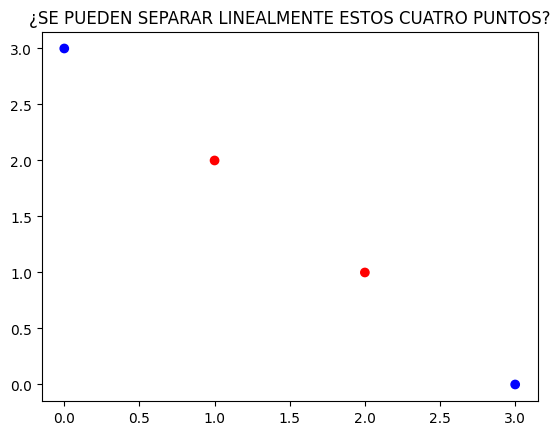

In [ ]:
# Define the coordinates of the points
x_values = [0, 1, 2, 3]
y_values = [3, 2, 1, 0]

# Define colors for the points
colors = ['blue', 'red', 'red', 'blue']

# Plot the points
plt.scatter(x_values, y_values, color=colors)
plt.title('¿SE PUEDEN SEPARAR LINEALMENTE ESTOS CUATRO PUNTOS?')

# Show the plot
plt.show()

### Cada una de las transformaciones propuestas

Ejemplo: Transformada x+y en (0,3) Azul ---> x = 0, y = 3 (Resultado = 3)

In [ ]:
data = {'Transformada': ['x+y', 'x*y', 'x**2'],
        '(0, 3) Azul': [3, np.nan, np.nan],
        '(1, 2) Rojo': [np.nan]*3,
        '(2, 1) Rojo': [np.nan]*3,
        '(3, 0) Azul': [np.nan]*3}


df = pd.DataFrame(data)
df

,Transformada,"(0, 3) Azul","(1, 2) Rojo","(2, 1) Rojo","(3, 0) Azul"
0,x+y,3.0,NaN,NaN,NaN
1,x*y,NaN,NaN,NaN,NaN
2,x**2,NaN,NaN,NaN,NaN


In [ ]:

data = {
    'Transformada': ['x+y', 'x*y', 'x**2'],
    '(0, 3) Azul': [0+3, 0*3, 0**2],
    '(1, 2) Rojo': [1+2, 1*2, 1**2],
    '(2, 1) Rojo': [2+1, 2*1, 2**2],
    '(3, 0) Azul': [3+0, 3*0, 3**2]
}

df = pd.DataFrame(data)
df


,Transformada,"(0, 3) Azul","(1, 2) Rojo","(2, 1) Rojo","(3, 0) Azul"
0,x+y,3,3,3,3
1,x*y,0,2,2,0
2,x**2,0,1,4,9


## Pasemos a graficar en GeoGebra 3D

https://www.geogebra.org/3d?lang=es

## Truco del Kernel

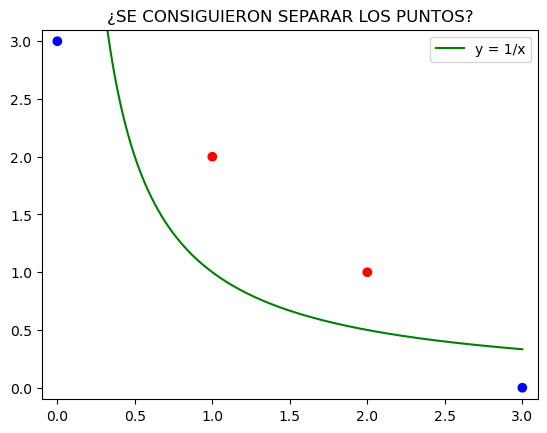

In [ ]:
# Define the coordinates of the points
x_values = [0, 1, 2, 3]
y_values = [3, 2, 1, 0]

# Define colors for the points
colors = ['blue', 'red', 'red', 'blue']

# Plot the points
plt.scatter(x_values, y_values, color=colors)

# Plot the parabola y = 1/x
x_parabola = np.linspace(0.1, 3, 400)  # Define range of x values for the parabola
y_parabola = 1 / x_parabola           # Calculate corresponding y values
plt.plot(x_parabola, y_parabola, color='green', label='y = 1/x')  # Plot the parabola

# Set limits for x and y axes
plt.xlim(-0.1, 3.1)  # Set limit for x-axis
plt.ylim(-0.1, 3.1)  # Set limit for y-axis

# Show the plot
plt.title('¿SE CONSIGUIERON SEPARAR LOS PUNTOS?')
plt.legend()  # Add legend
plt.show()

# El truco del kernel es utilizado por los siguientes dos kernels que veremos (Poly y RBF)

## KERNEL POLY

Al igual que el kernel lineal, toma en cuenta los puntos originales del dataset. Adicionalmente, también toma en cuenta su interacción, como se puede ver en la función con x1*x2.

Se utilizan los grados, donde grado 1 equivale a una separación lineal. Por ejemplo, en esta imagen se utiliza un grado 2 al elevar al cuadrado.

A mayor grado del kernel poly, mayor flexibilidad del límite de decisión.

![image.png](attachment:79951773-1185-4b11-9b7a-cb105da84875.png)

## KERNEL RBF

Su transformación es complicada y aparte dimensionalmente infinita, haciendo imposible su utilizización en un programa de computadora.

En cambio, la expresión en kernel es simple ||X₁ - X₂|| es la distancia euclidiana (norma L₂) entre dos puntos X₁ y X₂.

Donde γ (gamma) es un parámetro que define hasta dónde llega la influencia de un único ejemplo de entrenamiento, donde los valores bajos significan "lejos" y los valores altos significan "cerca"..

![image.png](attachment:39c0d552-ab00-4609-a6e9-cb135bb53e13.png)

# GRAFICACIONES INTERACTIVAS

### MSV: POLY (C, Grado), RBF (C, Gamma)

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn import svm, datasets
from ipywidgets import interactive, HBox, VBox, FloatSlider, IntSlider
from sklearn.preprocessing import StandardScaler
%matplotlib inline

# Generate sample data
X, y = datasets.make_moons(n_samples=100, noise=0.15, random_state=42)
scaler = StandardScaler()
X = scaler.fit_transform(X)

def plot_svm(X, y, kernel, C, degree=3, gamma='scale'):
    plt.figure(figsize=(6, 5))
    clf = svm.SVC(kernel=kernel, C=C, degree=degree, gamma=gamma)
    clf.fit(X, y)

    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.02),
                         np.arange(y_min, y_max, 0.02))
    Z = clf.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    plt.contourf(xx, yy, Z, alpha=0.8, cmap=plt.cm.RdYlBu)
    plt.scatter(X[:, 0], X[:, 1], c=y, cmap=plt.cm.RdYlBu, edgecolor='black')
    plt.xlim(xx.min(), xx.max())
    plt.ylim(yy.min(), yy.max())
    if kernel == 'poly':
        plt.title(f'SVM with {kernel} kernel\nC={C:.2f}, degree={degree}')
    else:
        plt.title(f'SVM with {kernel} kernel\nC={C:.2f}, gamma={gamma:.2f}')
    plt.show()

def plot_poly(C, degree):
    plot_svm(X, y, 'poly', C, degree=degree)

def plot_rbf(C, gamma):
    plot_svm(X, y, 'rbf', C, gamma=gamma)

poly_plot = interactive(plot_poly,
                        C=FloatSlider(min=0.1, max=10, step=0.1, value=1, description='C'),
                        degree=IntSlider(min=1, max=10, step=1, value=3, description='Degree'))

rbf_plot = interactive(plot_rbf,
                       C=FloatSlider(min=0.1, max=10, step=0.1, value=1, description='C'),
                       gamma=FloatSlider(min=0.01, max=10, step=0.01, value=1, description='Gamma'))

In [ ]:
display(HBox([VBox([poly_plot.children[-1], poly_plot.children[0], poly_plot.children[1]]),
              VBox([rbf_plot.children[-1], rbf_plot.children[0], rbf_plot.children[1]])]))

### MULTI CLASE DE 3

Las MSV también pueden cumplir con datasets que tengan más de dos clases

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn import svm, datasets
from ipywidgets import interactive, HBox, VBox, FloatSlider, IntSlider
from sklearn.preprocessing import StandardScaler
%matplotlib inline

# Load the iris dataset
iris = datasets.load_iris()
X_iris = iris.data[:, [0, 2]]  # we only take the first and third feature for visualization
y_iris = iris.target

scaler_iris = StandardScaler()
X_iris = scaler_iris.fit_transform(X_iris)

def plot_svm_iris(X, y, kernel, C, degree=3, gamma='scale'):
    plt.figure(figsize=(6, 5))
    clf = svm.SVC(kernel=kernel, C=C, degree=degree, gamma=gamma)
    clf.fit(X, y)

    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.02),
                         np.arange(y_min, y_max, 0.02))
    Z = clf.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    plt.contourf(xx, yy, Z, alpha=0.8, cmap=plt.cm.RdYlBu)
    plt.scatter(X[:, 0], X[:, 1], c=y, cmap=plt.cm.RdYlBu, edgecolor='black')
    plt.xlim(xx.min(), xx.max())
    plt.ylim(yy.min(), yy.max())
    if kernel == 'poly':
        plt.title(f'Iris SVM with {kernel} kernel\nC={C:.2f}, degree={degree}')
    else:
        plt.title(f'Iris SVM with {kernel} kernel\nC={C:.2f}, gamma={gamma:.2f}')
    plt.xlabel('Sepal length (standardized)')
    plt.ylabel('Petal length (standardized)')
    plt.show()

def plot_poly_iris(C, degree):
    plot_svm_iris(X_iris, y_iris, 'poly', C, degree=degree)

def plot_rbf_iris(C, gamma):
    plot_svm_iris(X_iris, y_iris, 'rbf', C, gamma=gamma)

poly_plot_iris = interactive(plot_poly_iris,
                             C=FloatSlider(min=0.1, max=10, step=0.1, value=1, description='C'),
                             degree=IntSlider(min=1, max=10, step=1, value=3, description='Degree'))

rbf_plot_iris = interactive(plot_rbf_iris,
                            C=FloatSlider(min=0.1, max=10, step=0.1, value=1, description='C'),
                            gamma=FloatSlider(min=0.01, max=10, step=0.01, value=1, description='Gamma'))

In [ ]:
display(HBox([VBox([poly_plot_iris.children[-1], poly_plot_iris.children[0], poly_plot_iris.children[1]]),
              VBox([rbf_plot_iris.children[-1], rbf_plot_iris.children[0], rbf_plot_iris.children[1]])]))

## MULTI-CLASE DE 10 (La graficación ya no se ve limpia)

Las MSV cumplen con datasets de n dimensiones. Aquí para su graficación se tuvo que hacer PCA para obtener las dos de mayor peso, lo cual genera una gráfica no tan comprensible en los límites de decisión.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn import svm, datasets, decomposition
from ipywidgets import interactive, HBox, VBox, FloatSlider, IntSlider
from sklearn.preprocessing import StandardScaler
%matplotlib inline

# Load the digits dataset
digits = datasets.load_digits()
X_digits = digits.data
y_digits = digits.target
categories = list(np.unique(digits.target))

# Preprocess the data
scaler_digits = StandardScaler()
X_digits_scaled = scaler_digits.fit_transform(X_digits)

# Apply PCA
pca_digits = decomposition.PCA(n_components=2)
X_digits_pca = pca_digits.fit_transform(X_digits_scaled)

# Create a coarser grid for faster plotting
x_min_digits, x_max_digits = X_digits_pca[:, 0].min() - 1, X_digits_pca[:, 0].max() + 1
y_min_digits, y_max_digits = X_digits_pca[:, 1].min() - 1, X_digits_pca[:, 1].max() + 1
xx_digits, yy_digits = np.meshgrid(np.linspace(x_min_digits, x_max_digits, 50),
                                   np.linspace(y_min_digits, y_max_digits, 50))

def plot_svm_digits(X, y, kernel, C, degree=3, gamma='scale'):
    plt.figure(figsize=(8, 6))
    clf = svm.SVC(kernel=kernel, C=C, degree=degree, gamma=gamma)
    clf.fit(X, y)

    Z = clf.predict(np.c_[xx_digits.ravel(), yy_digits.ravel()])
    Z = Z.reshape(xx_digits.shape)

    plt.contourf(xx_digits, yy_digits, Z, alpha=0.8, cmap=plt.cm.RdYlBu)
    #scatter = plt.scatter(X[:, 0], X[:, 1], c=y, cmap=plt.cm.RdYlBu, edgecolor='black')


    # Create a scatter plot for each category
    scatter_plots = []
    for i, category in enumerate(categories):
        mask = y == i
        scatter = plt.scatter(X[mask, 0], X[mask, 1], c=[plt.cm.RdYlBu(i/len(categories))], edgecolor='black', label=category)
        scatter_plots.append(scatter)

    plt.xlim(xx_digits.min(), xx_digits.max())
    plt.ylim(yy_digits.min(), yy_digits.max())
    if kernel == 'poly':
        plt.title(f'Digits SVM with {kernel} kernel\nC={C:.2f}, degree={degree}')
    else:
        plt.title(f'Digits SVM with {kernel} kernel\nC={C:.2f}, gamma={gamma:.2f}')
    plt.xlabel('First Principal Component')
    plt.ylabel('Second Principal Component')

    # Add legend
    plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))

    plt.tight_layout()
    plt.show()

def plot_poly_digits(C, degree):
    plot_svm_digits(X_digits_pca, y_digits, 'poly', C, degree=degree)

def plot_rbf_digits(C, gamma):
    plot_svm_digits(X_digits_pca, y_digits, 'rbf', C, gamma=gamma)

poly_plot_digits = interactive(plot_poly_digits,
                               C=FloatSlider(min=0.1, max=10, step=0.1, value=1, description='C'),
                               degree=IntSlider(min=1, max=5, step=1, value=3, description='Degree'))

rbf_plot_digits = interactive(plot_rbf_digits,
                              C=FloatSlider(min=0.1, max=10, step=0.1, value=1, description='C'),
                              gamma=FloatSlider(min=0.01, max=2, step=0.01, value=0.1, description='Gamma'))

In [ ]:
display(HBox([VBox([poly_plot_digits.children[-1], poly_plot_digits.children[0], poly_plot_digits.children[1]]),
              VBox([rbf_plot_digits.children[-1], rbf_plot_digits.children[0], rbf_plot_digits.children[1]])]))

## MULTI-CLASE UTILIZANDO SPARSE MATRIX (estas serán utilizadas en su tarea, no recomendable graficar)

Aquí se aprecia un ejemplo utilizando sparse matrix, el cual para su graficación debe limitar los features del vectorizer aparte de ahora utilizar TruncatedSVD para obtener los dos componentes de mayor peso, lo que genera una graficación que no hace justicia con la separación real, debido a bajar las dimensiones.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn import svm, datasets
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import TruncatedSVD
from sklearn.preprocessing import StandardScaler
from ipywidgets import interactive, HBox, VBox, FloatSlider, IntSlider
from sklearn.datasets import fetch_20newsgroups
%matplotlib inline

# Fetch data (limiting to 1000 samples)
categories = ['alt.atheism', 'comp.graphics', 'sci.med', 'soc.religion.christian', 'talk.politics.guns']
newsgroups = fetch_20newsgroups(subset='train', categories=categories, random_state=42)

# Create sparse matrix (using fewer features)
vectorizer = TfidfVectorizer(max_features=1000)
X_sparse = vectorizer.fit_transform(newsgroups.data)
y_sparse = newsgroups.target

# Reduce dimensionality
svd = TruncatedSVD(n_components=2, random_state=42)
X_sparse_reduced = svd.fit_transform(X_sparse)

scaler_sparse = StandardScaler()
X_sparse_scaled = scaler_sparse.fit_transform(X_sparse_reduced)

# Create mesh grid once
x_min, x_max = X_sparse_scaled[:, 0].min() - 1, X_sparse_scaled[:, 0].max() + 1
y_min, y_max = X_sparse_scaled[:, 1].min() - 1, X_sparse_scaled[:, 1].max() + 1
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 100),
                     np.linspace(y_min, y_max, 100))
mesh = np.c_[xx.ravel(), yy.ravel()]

def plot_svm_sparse(X, y, kernel, C, degree=3, gamma='scale'):
    plt.figure(figsize=(10, 8))
    clf = svm.SVC(kernel=kernel, C=C, degree=degree, gamma=gamma)
    clf.fit(X, y)

    Z = clf.predict(mesh)
    Z = Z.reshape(xx.shape)

    plt.contourf(xx, yy, Z, alpha=0.8, cmap=plt.cm.RdYlBu)

    # Create a scatter plot for each category
    scatter_plots = []
    for i, category in enumerate(categories):
        mask = y == i
        scatter = plt.scatter(X[mask, 0], X[mask, 1], c=[plt.cm.RdYlBu(i/len(categories))], edgecolor='black', label=category)
        scatter_plots.append(scatter)

    plt.xlim(xx.min(), xx.max())
    plt.ylim(yy.min(), yy.max())
    if kernel == 'poly':
        plt.title(f'Newsgroups SVM with {kernel} kernel\nC={C:.2f}, degree={degree}')
    else:
        plt.title(f'Newsgroups SVM with {kernel} kernel\nC={C:.2f}, gamma={gamma:.2f}')
    plt.xlabel('First SVD component')
    plt.ylabel('Second SVD component')

    # Add legend
    plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))

    plt.tight_layout()
    plt.show()

def plot_poly_sparse(C, degree):
    plot_svm_sparse(X_sparse_scaled, y_sparse, 'poly', C, degree=degree)

def plot_rbf_sparse(C, gamma):
    plot_svm_sparse(X_sparse_scaled, y_sparse, 'rbf', C, gamma=gamma)

poly_plot_sparse = interactive(plot_poly_sparse,
                               C=FloatSlider(min=0.1, max=10, step=0.1, value=1, description='C'),
                               degree=IntSlider(min=1, max=5, step=1, value=3, description='Degree'))

rbf_plot_sparse = interactive(plot_rbf_sparse,
                              C=FloatSlider(min=0.1, max=10, step=0.1, value=1, description='C'),
                              gamma=FloatSlider(min=0.01, max=2, step=0.01, value=0.1, description='Gamma'))

In [ ]:
display(HBox([VBox([poly_plot_sparse.children[-1], poly_plot_sparse.children[0], poly_plot_sparse.children[1]]),
              VBox([rbf_plot_sparse.children[-1], rbf_plot_sparse.children[0], rbf_plot_sparse.children[1]])]))

# GRID SEARCH

La búsqueda de cuadrícula (Grid Search) es un método para encontrar la mejor combinación posible de hiperparámetros en la que el modelo logra la mayor exactitud (*accuracy*).

Antes de aplicar la búsqueda de cuadrícula en cualquier algoritmo, los datos se dividen en conjuntos de entrenamiento y validación, y se utiliza un conjunto de validación para validar los modelos.

### GRID SEARCH POLY

Best parameters: {'svm__C': 10, 'svm__degree': 1, 'svm__kernel': 'poly'}
Best cross-validation score: 0.86

Classification Report:
              precision    recall  f1-score   support

           0       0.83      0.81      0.82       100
           1       0.81      0.83      0.82       100

    accuracy                           0.82       200
   macro avg       0.82      0.82      0.82       200
weighted avg       0.82      0.82      0.82       200

Test set accuracy: 0.820


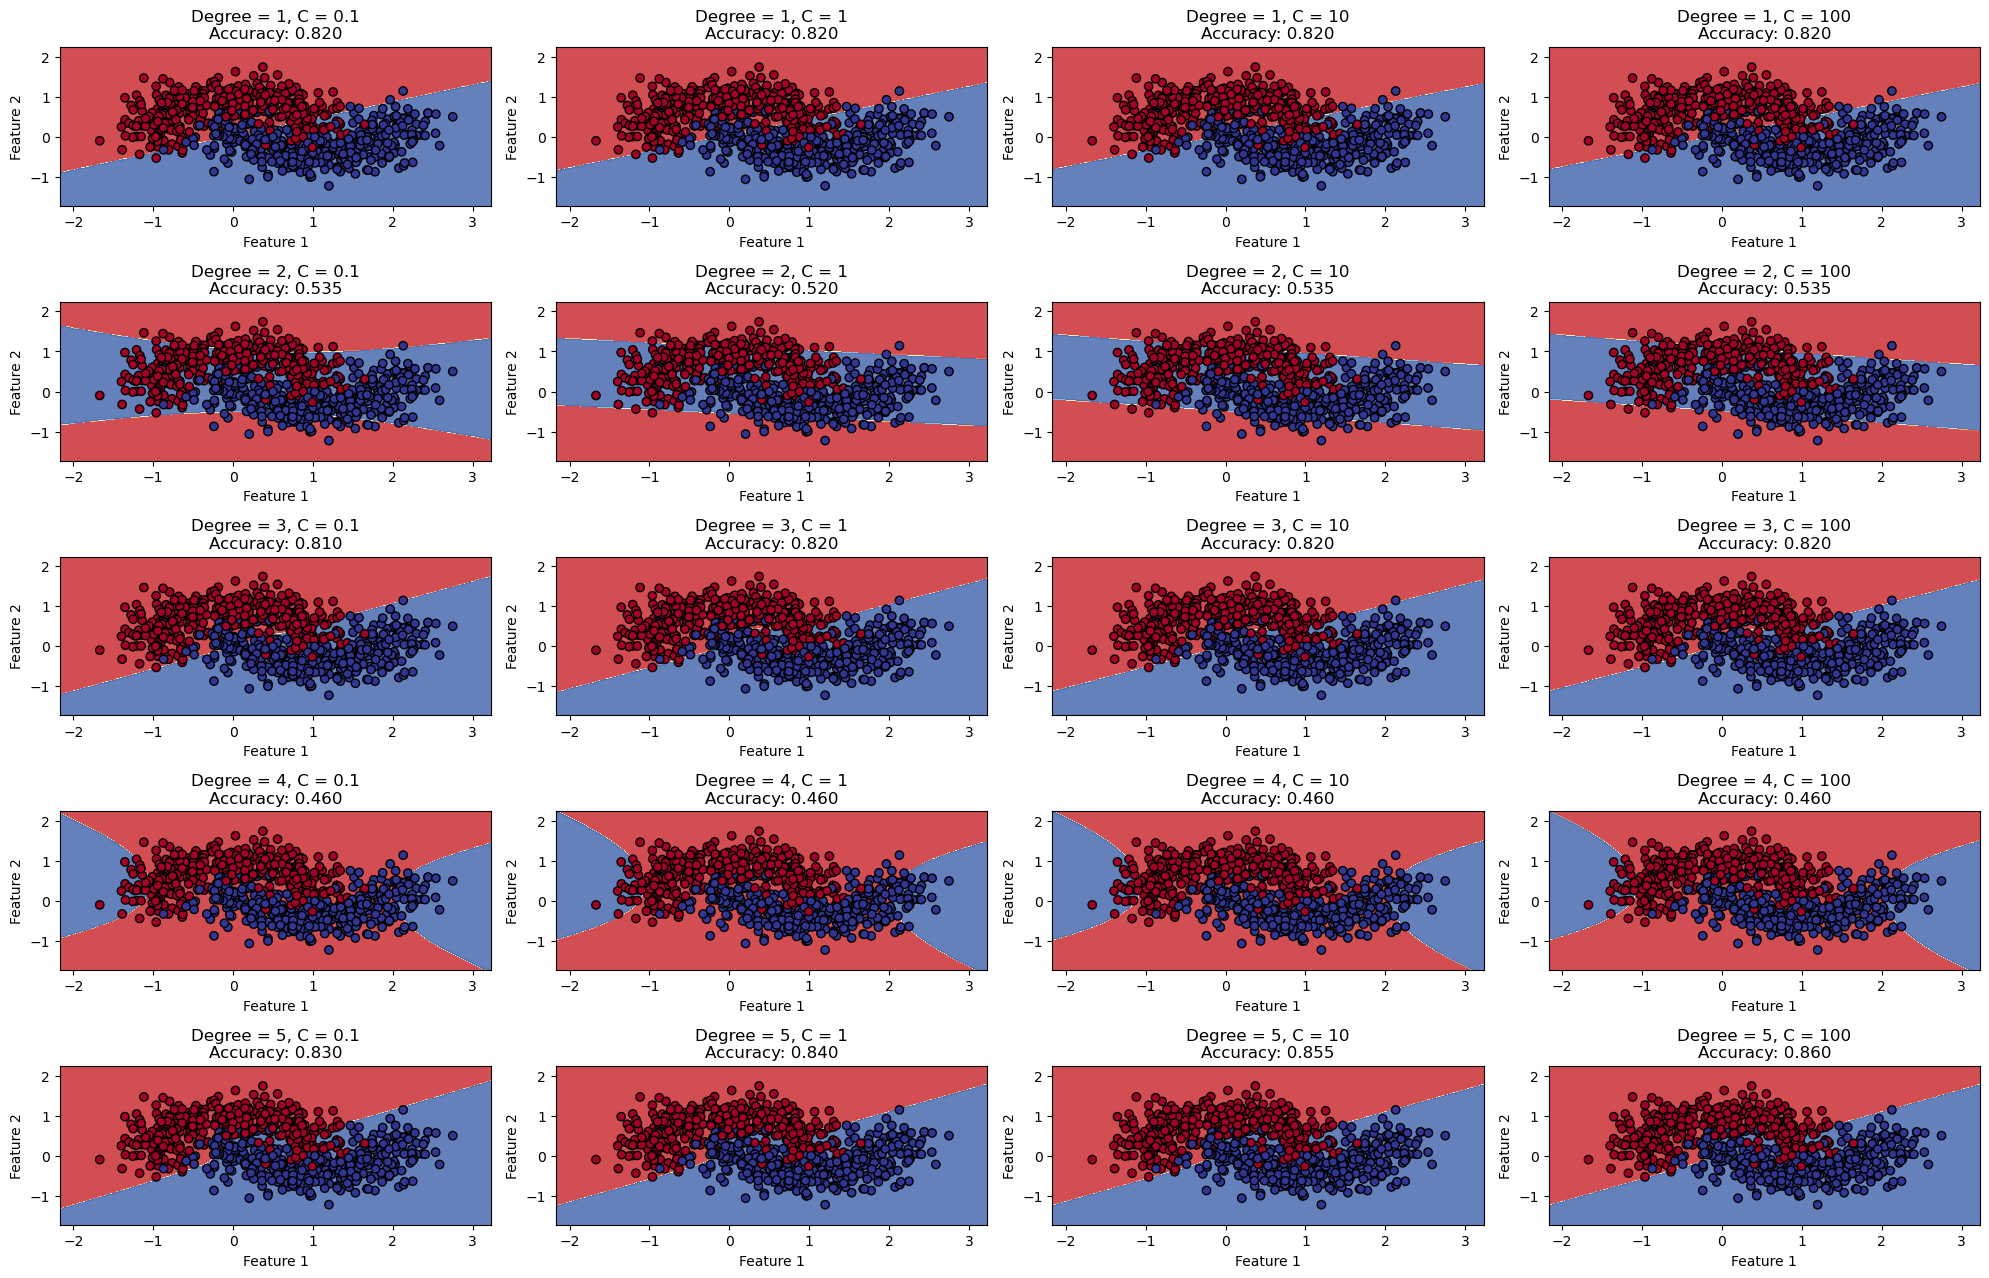

Best degree value found: 1
Best C value found: 10
Accuracy of best model: 0.820
Accuracy of manual best model: 0.820


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, accuracy_score

def plot_decision_boundary(X, y, model, title, accuracy):
    x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
    y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
    xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.02),
                         np.arange(y_min, y_max, 0.02))
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)
    plt.contourf(xx, yy, Z, alpha=0.8, cmap=plt.cm.RdYlBu)
    plt.scatter(X[:, 0], X[:, 1], c=y, cmap=plt.cm.RdYlBu, edgecolor='black')
    plt.title(f"{title}\nAccuracy: {accuracy:.3f}")
    plt.xlabel('Feature 1')
    plt.ylabel('Feature 2')

# Generate the moons dataset
X_moons, y_moons = make_moons(n_samples=1000, noise=0.3, random_state=42)

# Split the data into training and testing sets
X_train_moons, X_test_moons, y_train_moons, y_test_moons = train_test_split(X_moons, y_moons, test_size=0.2, random_state=42)

# Create a pipeline with scaling and SVM
pipeline_moons = Pipeline([
    ('scaler', StandardScaler()),
    ('svm', SVC())
])

# Calculate default gamma value (1 / n_features)
n_features = X_train_moons.shape[1]
default_gamma = 1 / n_features

# Define the parameter grid for GridSearch
param_grid_moons = [
    {'svm__kernel': ['poly'],
     'svm__C': [0.1, 1, 10, 100],
     'svm__degree': [1, 2, 3, 4, 5]}  # Logarithmic range from 10^-3 to 10^3
]

# Create GridSearchCV object
grid_search_moons = GridSearchCV(pipeline_moons, param_grid_moons, cv=5, scoring='accuracy', n_jobs=-1)

# Fit the GridSearchCV
grid_search_moons.fit(X_train_moons, y_train_moons)

# Print the best parameters and score
print("Best parameters:", grid_search_moons.best_params_)
print("Best cross-validation score:", grid_search_moons.best_score_)

# Make predictions on the test set
y_pred_moons = grid_search_moons.predict(X_test_moons)

# Generate and print the classification report
report_moons = classification_report(y_test_moons, y_pred_moons)
print("\nClassification Report:")
print(report_moons)

# Calculate and print the test set accuracy
test_accuracy = accuracy_score(y_test_moons, y_pred_moons)
print(f"Test set accuracy: {test_accuracy:.3f}")

# Visualize decision boundaries for different gamma values
plt.figure(figsize=(20, 15))
degree_values = [1, 2, 3, 4, 5]
C_values = [0.1, 1, 10, 100]

for i, degree in enumerate(degree_values):
    for j, C in enumerate(C_values):
        # Create a new pipeline with the current gamma and C values
        current_pipeline = Pipeline([
            ('scaler', StandardScaler()),
            ('svm', SVC(kernel='poly', C=C, degree=degree))
        ])
        current_pipeline.fit(X_train_moons, y_train_moons)

        # Calculate accuracy using the full pipeline
        y_pred = current_pipeline.predict(X_test_moons)
        accuracy = accuracy_score(y_test_moons, y_pred)

        plt.subplot(6, 4, i*4 + j + 1)
        plot_decision_boundary(X_train_moons, y_train_moons, current_pipeline, f'Degree = {degree}, C = {C}', accuracy)

plt.tight_layout()
plt.show()

print(f"Best degree value found: {grid_search_moons.best_params_['svm__degree']}")
print(f"Best C value found: {grid_search_moons.best_params_['svm__C']}")

# Verify the accuracy of the best model
best_pipeline = grid_search_moons.best_estimator_
best_predictions = best_pipeline.predict(X_test_moons)
best_accuracy = accuracy_score(y_test_moons, best_predictions)
print(f"Accuracy of best model: {best_accuracy:.3f}")

# Compare with the plot for best parameters
best_degree = grid_search_moons.best_params_['svm__degree']
best_C = grid_search_moons.best_params_['svm__C']
best_pipeline_manual = Pipeline([
    ('scaler', StandardScaler()),
    ('svm', SVC(kernel='poly', C=best_C, degree=best_degree))
])
best_pipeline_manual.fit(X_train_moons, y_train_moons)
best_manual_predictions = best_pipeline_manual.predict(X_test_moons)
best_manual_accuracy = accuracy_score(y_test_moons, best_manual_predictions)
print(f"Accuracy of manual best model: {best_manual_accuracy:.3f}")

# PREGUNTA

### **Como pueden observar, el poly con grado 5 y C 100 dio una accuracy mayor en las gráficas que los parametros elegidos como los 'mejores', ¿Por qué creen que ocurrió esto?**

Esto puede deberse a que el proceso de selección de hiperparámetros (como la validación cruzada) no siempre encuentre la combinación óptima global, especialmente si el espacio de búsqueda es limitado. El modelo con poly, grado=5 y C=100puede haber coincidido mejor con la distribución real de los datos de prueba, incluso si en validación no se comporta tan bien. En otras palabras, podría estar ocurriendo un sobreajuste a la validación cruzada , y el modelo con grado 5 y C alto logró generalizar mejor en el conjunto de prueba.

### GRID SEARCH RBF

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, accuracy_score

def plot_decision_boundary(X, y, model, title, accuracy):
    x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
    y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
    xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.02),
                         np.arange(y_min, y_max, 0.02))
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)
    plt.contourf(xx, yy, Z, alpha=0.8, cmap=plt.cm.RdYlBu)
    plt.scatter(X[:, 0], X[:, 1], c=y, cmap=plt.cm.RdYlBu, edgecolor='black')
    plt.title(f"{title}\nAccuracy: {accuracy:.3f}")
    plt.xlabel('Feature 1')
    plt.ylabel('Feature 2')

# Generate the moons dataset
X_moons, y_moons = make_moons(n_samples=1000, noise=0.3, random_state=42)

# Split the data into training and testing sets
X_train_moons, X_test_moons, y_train_moons, y_test_moons = train_test_split(X_moons, y_moons, test_size=0.2, random_state=42)

# Create a pipeline with scaling and SVM
pipeline_moons = Pipeline([
    ('scaler', StandardScaler()),
    ('svm', SVC())
])

# Calculate default gamma value (1 / n_features)
n_features = X_train_moons.shape[1]
default_gamma = 1 / n_features

# Define the parameter grid for GridSearch
param_grid_moons = [
    {'svm__kernel': ['rbf'],
     'svm__C': [0.1, 1, 10, 100],
     'svm__gamma': np.logspace(-3, 3, 7)}  # Logarithmic range from 10^-3 to 10^3
]

# Create GridSearchCV object
grid_search_moons = GridSearchCV(pipeline_moons, param_grid_moons, cv=5, scoring='accuracy', n_jobs=-1)

# Fit the GridSearchCV
grid_search_moons.fit(X_train_moons, y_train_moons)

# Print the best parameters and score
print("Best parameters:", grid_search_moons.best_params_)
print("Best cross-validation score:", grid_search_moons.best_score_)

# Make predictions on the test set
y_pred_moons = grid_search_moons.predict(X_test_moons)

# Generate and print the classification report
report_moons = classification_report(y_test_moons, y_pred_moons)
print("\nClassification Report:")
print(report_moons)

# Calculate and print the test set accuracy
test_accuracy = accuracy_score(y_test_moons, y_pred_moons)
print(f"Test set accuracy: {test_accuracy:.3f}")

# Visualize decision boundaries for different gamma values
plt.figure(figsize=(20, 15))
gamma_values = [0.01, 0.1, 1, 10, 100]
C_values = [0.1, 1, 10, 100]

for i, gamma in enumerate(gamma_values):
    for j, C in enumerate(C_values):
        # Create a new pipeline with the current gamma and C values
        current_pipeline = Pipeline([
            ('scaler', StandardScaler()),
            ('svm', SVC(kernel='rbf', C=C, gamma=gamma))
        ])
        current_pipeline.fit(X_train_moons, y_train_moons)

        # Calculate accuracy using the full pipeline
        y_pred = current_pipeline.predict(X_test_moons)
        accuracy = accuracy_score(y_test_moons, y_pred)

        plt.subplot(6, 4, i*4 + j + 1)
        plot_decision_boundary(X_train_moons, y_train_moons, current_pipeline, f'Gamma = {gamma}, C = {C}', accuracy)

plt.tight_layout()
plt.show()

print(f"Best gamma value found: {grid_search_moons.best_params_['svm__gamma']}")
print(f"Best C value found: {grid_search_moons.best_params_['svm__C']}")

# Verify the accuracy of the best model
best_pipeline = grid_search_moons.best_estimator_
best_predictions = best_pipeline.predict(X_test_moons)
best_accuracy = accuracy_score(y_test_moons, best_predictions)
print(f"Accuracy of best model: {best_accuracy:.3f}")

# Compare with the plot for best parameters
best_gamma = grid_search_moons.best_params_['svm__gamma']
best_C = grid_search_moons.best_params_['svm__C']
best_pipeline_manual = Pipeline([
    ('scaler', StandardScaler()),
    ('svm', SVC(kernel='rbf', C=best_C, gamma=best_gamma))
])
best_pipeline_manual.fit(X_train_moons, y_train_moons)
best_manual_predictions = best_pipeline_manual.predict(X_test_moons)
best_manual_accuracy = accuracy_score(y_test_moons, best_manual_predictions)
print(f"Accuracy of manual best model: {best_manual_accuracy:.3f}")

Best parameters: {'svm__C': 1, 'svm__gamma': 10.0, 'svm__kernel': 'rbf'}
Best cross-validation score: 0.9137500000000001

Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.95      0.94       100
           1       0.95      0.93      0.94       100

    accuracy                           0.94       200
   macro avg       0.94      0.94      0.94       200
weighted avg       0.94      0.94      0.94       200

Test set accuracy: 0.940


# GRIDSEARCH EN CONJUNTO (LINEAR, POLY, RBF) Y GUARDAR EL MEJOR MODELO

A continuación usaremos la dataset de digits (la cual ya vimos que graficada no da claridad); simplemente nos centraremos en hacer GridSearch y que nos regrese los mejores parámetros con base en la validación cruzada y finalmente obtener su resultado con los datos de test.

# PREGUNTA

## ¿Por qué se debe guardar el mejor modelo?

Guardar el mejor modelo es importante porque te permite reutilizar el modelo más preciso sin tener que reentrenarlo desde cero. cada vez . Esto es fundamentalcada vez. Esto es fundamental para ahorrar tiempo, recursos computacionales y asegurar la reproducibilidad del experimento. Además, si el modelo se va a usar en producción o para hacer predicciones futuras, es necesario tener disponible exactamente el modelo que mostró el mejor desempeño en la etapa de validación y prueba.

In [ ]:
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.svm import SVC
from sklearn.metrics import classification_report, accuracy_score
from sklearn.preprocessing import StandardScaler
import numpy as np
from joblib import dump
import os

# Load the digits dataset
digits = load_digits()
X_, y_ = digits.data, digits.target

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X_, y_, test_size=0.2, random_state=42)

# Scale the features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Calculate default gamma value (1 / n_features)
n_features = X_train.shape[1]
default_gamma = 1 / n_features

# Define parameter grid
param_grid = [
    {'kernel': ['linear'], 'C': [0.1, 1, 10, 100]},
    {'kernel': ['poly'], 'C': [0.1, 1, 10, 100], 'degree': [2, 3, 4, 5]},
    {'kernel': ['rbf'], 'C': [0.1, 1, 10, 100], 'gamma': [0.001, 0.01, 0.1, 1, 10, 100, 'scale', 'auto']}
]

# Initialize GridSearchCV
grid_search = GridSearchCV(SVC(), param_grid, cv=5, scoring='accuracy', n_jobs=-1)

# Fit the grid search to the data
grid_search.fit(X_train_scaled, y_train)

# Print the best parameters and score
print("Best parameters:", grid_search.best_params_)
print("Best cross-validation score:", grid_search.best_score_)

# Make predictions on the test set
y_pred = grid_search.predict(X_test_scaled)

# Generate and print the classification report
report = classification_report(y_test, y_pred)
print("\nClassification Report:")
print(report)

# Calculate and print the test set accuracy
test_accuracy = accuracy_score(y_test, y_pred)
print(f"Test set accuracy: {test_accuracy:.3f}")



# SAVE THE BEST MODEL
best_model = grid_search.best_estimator_
model_filename = 'best_model_seccion1.joblib'
dump(best_model, model_filename)
print(f"\nBest model saved as {model_filename}")

# Optionally, save the entire GridSearchCV object
gridsearch_filename = 'gridsearch_results_seccion1.joblib'
dump(grid_search, gridsearch_filename)
print(f"Full GridSearchCV results saved as {gridsearch_filename}")